# Replicating ViT
https://arxiv.org/abs/2010.11929

- A **Transformer architecture** is generally considered to be any neural network that uses the attention mechanism) as its primary learning layer. Similar to how a convolutional neural network (CNN) uses convolutions as its primary learning layer.

# 0. Getting Setup

In [6]:
import torch
print(f'Torch version: {torch.__version__}')
import torchvision
print(f'Torchvision version: {torchvision.__version__}')
import torchinfo
print(f'Torchinfo version: {torchinfo.__version__}')
from torchinfo import summary


Torch version: 2.8.0
Torchvision version: 0.23.0
Torchinfo version: 1.8.0


In [8]:
#device
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

# 1. Get Data

In [13]:
#download the data from github
import requests
import zipfile
from pathlib import Path

link = "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"

#function to download the data
def download_data(url, destination_folder):
    # Convert to Path object
    destination_folder = Path(destination_folder)
    zip_path = destination_folder.with_suffix('.zip')
    
    #if the folder exists, don't download the data again
    if destination_folder.exists():
        print(f"Directory {destination_folder} already exists, skipping download...")
        return
    
    # Download the data
    print(f"Downloading data from {url}...")
    response = requests.get(url)
    response.raise_for_status()  # Raise an error for bad status codes
    
    # Save the zip file
    print(f"Saving zip file to {zip_path}...")
    with open(zip_path, "wb") as f:
        f.write(response.content)
    
    # Extract the zip file
    print(f"Extracting zip file to {destination_folder}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(destination_folder.parent)
    
    # Remove the zip file after extraction
    zip_path.unlink()
    print(f"Download and extraction complete! Data available at {destination_folder}")

#download the data
download_data(link, "pizza_steak_sushi")

Saving zip file to pizza_steak_sushi.zip...
Extracting zip file to pizza_steak_sushi...
Download and extraction complete! Data available at pizza_steak_sushi


In [19]:
train_dir = "train"
test_dir = "test"

# 2. Create datasets and dataloaders

In [26]:
#create datasets
from torchvision import datasets

#transform the data
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(root=train_dir, transform=transform)
test_data = datasets.ImageFolder(root=test_dir, transform=transform)

#create dataloaders
from torch.utils.data import DataLoader
from torchvision import transforms

train_dataloader = DataLoader(train_data, batch_size=4096, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=4096, shuffle=False)


In [37]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

### Visualize a single image

In [42]:
img, label = next(iter(train_dataloader))

In [46]:
img[0].shape, label[0]

(torch.Size([3, 224, 224]), tensor(0))

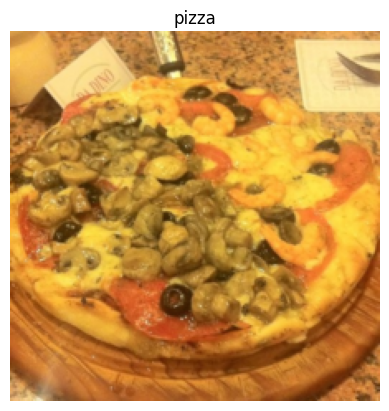

In [47]:
#plot the image
import matplotlib.pyplot as plt

plt.imshow(img[0].permute(1, 2, 0)) #permute the image to (height, width, color)
plt.title(class_names[label[0]])
plt.axis(False)
plt.show()
